# PPO from scratch — **V3: GAE-λ advantage**

Fourth of six. V2 gave you a fixed-horizon buffer with correct bootstrapping. V3 changes *how you
estimate the advantage* — the single number that tells the policy "was this action better or worse
than expected."

| Version | Concept |
|---|---|
| V0 | Vanilla PG |
| V1 | Learned value baseline (critic) |
| V2 | Fixed-horizon rollout buffer + bootstrapping |
| **V3 (this)** | **GAE-λ advantage** |
| V4 | PPO-clip surrogate + multiple update passes |
| V5 | KL early-stop + advantage normalization |

### The two estimators you already know, and the dial between them
Your advantage so far was `A_t = R2G_t − V(s_t)` — the *full* discounted return minus the baseline.
That return is a Monte-Carlo sum of **real** rewards all the way to the horizon: **unbiased**, but it
carries the noise of every future action → **high variance**.

The other extreme is the one-step **TD residual**

$$\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$$

It uses one real reward and then trusts the critic for the rest: **low variance**, but **biased** by
however wrong `V` currently is.

**GAE-λ is the exponential dial between them.** It's a discounted sum of *future* TD residuals:

$$A^{\text{GAE}}_t = \sum_{l\ge0} (\gamma\lambda)^l\,\delta_{t+l}$$

- `λ → 0`  → `A_t = δ_t`, the one-step TD estimate (max bias, min variance).
- `λ → 1`  → `A_t = R2G_t − V(s_t)`, your V2 estimator (min bias, max variance).
- `λ = 0.95` (default) sits near the low-variance end while keeping most of the bias gone — almost
  always a better bias/variance trade than either extreme.

### What actually changes from V2
1. The buffer must now store the **rollout-time value `V(s_t)` for every step** — you need
   `V(s_t)` *and* `V(s_{t+1})` to form each `δ_t`. This is why V2's "just recompute `V` from obs
   later" shortcut ends here: `δ` is a *per-step* quantity.
2. `finish_trajectory` computes the **GAE advantage** (new) alongside the reward-to-go **return
   target** (unchanged — still the critic's regression target).
3. The policy update weights by `adv` straight from the buffer. No post-hoc `ret − V` — the values
   were frozen at rollout time, which is exactly the property V4 (multiple update passes) will need.

### ✅ Done-when
- The **GAE unit test** (given) passes — your `δ`/λ recursion is exact.
- `goals` still climb 0 → ~45 and training return still reaches ≈ −85. V3 is a *variance* change,
  not a capability jump — expect V2-ish means, ideally a bit **steadier** epoch-to-epoch.
- Greedy eval stays in V1/V2 territory (≈ −80 to −120). If `goals` crater, your `δ` indexing
  (`V(s_{t+1})` vs `V(s_t)`) or the `γλ` discount is off.

> Kernel: `ppo`. Policy, critic, losses, and the eval harness are your V2 code, unchanged.


## Imports & configuration *(given — V3 adds the λ knob)*


In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.distributions.categorical import Categorical
import torch.nn.functional as F
import gymnasium as gym
from gymnasium.spaces import Discrete, Box

ENV_NAME   = "Acrobot-v1"
SEED       = 0
HIDDEN     = [64, 64]
LR         = 1e-2
EPOCHS     = 15
GAMMA      = 0.99

# ---- NEW in V2 --------------------------------------------------------------
STEPS_PER_EPOCH = 4000     # fixed transitions collected per epoch (replaces "32 episodes")

LAM             = 0.95     # GAE-lambda: bias/variance dial (0 = one-step TD, 1 = full reward-to-go)

VALUE_LR        = 1e-2
VALUE_FIT_ITERS = 80

print("gymnasium", gym.__version__, "| torch", torch.__version__)


gymnasium 1.3.0 | torch 2.13.0+cpu


## Policy, critic, losses, helpers *(given — your V1 code, unchanged)*


In [2]:
class MyPolicy(nn.Module):
    def __init__(self, input_size: int, output_size: int) -> None:
        super().__init__()
        sizes = [input_size] + HIDDEN + [output_size]
        layers = []
        for in_sz, out_sz in zip(sizes, sizes[1:]):
            layers.append(nn.Linear(in_sz, out_sz))
            layers.append(nn.Tanh())
        layers = layers[:-1]
        self.linear_layers = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> Categorical:
        return Categorical(logits=self.linear_layers(x))

    def greedy(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layers(x).argmax()

    def sample(self, x: torch.Tensor) -> torch.Tensor:
        return self(x).sample()


class MyCritic(nn.Module):
    def __init__(self, input_size: int) -> None:
        super().__init__()
        sizes = [input_size] + HIDDEN
        layers = []
        for in_sz, out_sz in zip(sizes, sizes[1:]):
            layers.append(nn.Linear(in_sz, out_sz))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(HIDDEN[-1], 1))
        self.linear_layers = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layers(x).squeeze(-1)


def reward_to_go(rews: list[float], gamma: float = GAMMA) -> list[float]:
    """Discounted reward-to-go for a sequence. Handy for the buffer: append a bootstrap
    value to the rewards, take reward_to_go, and drop the last element."""
    n = len(rews)
    gamma_pows = gamma ** np.arange(n)
    cum_rews = []
    for i in range(n):
        left = n - i
        cr = (np.asarray(rews[i:]) * gamma_pows[:left]).sum()
        cum_rews.append(cr)
    return cum_rews


def compute_loss(policy: MyPolicy, obs: torch.Tensor, act: torch.Tensor,
                 weights: torch.Tensor) -> torch.Tensor:
    logp = policy(obs).log_prob(act)
    return -((logp) * weights).mean()


def compute_value_loss(critic: MyCritic, obs: torch.Tensor, returns: torch.Tensor) -> torch.Tensor:
    return F.mse_loss(critic(obs), returns)


def make_env(env_name: str = ENV_NAME, render_mode: str | None = None) -> gym.Env:
    return gym.make(env_name, render_mode=render_mode)


def set_seed(env: gym.Env, seed: int = SEED) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    env.reset(seed=seed)
    env.action_space.seed(seed)


_e = make_env()
OBS_DIM = _e.observation_space.shape[0]
N_ACTS  = _e.action_space.n
MAX_STEPS = _e.spec.max_episode_steps
print(f"{ENV_NAME}: obs_dim={OBS_DIM}, n_acts={N_ACTS}, max_steps={MAX_STEPS}")
_e.close()


Acrobot-v1: obs_dim=6, n_acts=3, max_steps=500


## 1. The rollout buffer — now value-aware *(you implement)*

Two changes from your V2 buffer:

- **`append(obs, action, reward, val)`** — one extra field: the rollout-time value `V(s_t)` of the
  state you're acting from. Store it per step.
- **`finish_trajectory(last_val)`** — compute **two** things for the just-finished path:
  - the **return target** `ret_t` — *unchanged* from V2: reward-to-go of this path's rewards with
    `last_val` appended as the bootstrap, dropping the last element. Still the critic's regression
    target.
  - the **GAE advantage** `adv_t` — *new*. Build the per-step TD residuals and take their discounted
    sum at rate `γλ`:

    ```
    vals   = [v_0, ..., v_{T-1}, last_val]        # append the bootstrap as the (T+1)-th value
    δ_t    = r_t + γ · vals[t+1] − vals[t]
    adv_t  = Σ_{l≥0} (γλ)^l · δ_{t+l}
    ```

`get_data()` now returns **four** tensors: `(obs, act, ret, adv)`.

**Reuse `reward_to_go`.** It's a discounted cumulative sum — call it with `gamma=GAMMA` on the
rewards for `ret`, and with `gamma=GAMMA*LAM` on the `δ` sequence for `adv`. Same function, two
rates; getting the rate right on each is the whole exercise (echo of the V2 gamma trap).


In [3]:
def gae(rewards: list[float], values: list[float], final_value: float,
        lamb: float, gamma: float) -> list[float]:
    V = values + [final_value]
    n = len(rewards)
    deltas = []
    for t in range(n):
        deltas.append( rewards[t] + gamma*V[t+1] - V[t])
    deltas = np.array(deltas)
    adventages = np.zeros(n, dtype=np.float32)
    adventages[-1] = deltas[-1]
    for t in reversed(range(n-1)):
        adventages[t] =  deltas[t] + gamma * lamb * adventages[t+1]
    return adventages.tolist()

    

In [4]:
class RolloutBuffer:
    # TODO (V3): your V2 buffer, made value-aware.
    #   __init__(max_steps):            per-step obs/act/rew/val storage + finished ret/adv storage.
    #   append(obs, action, reward, val): store one transition INCLUDING its rollout-time value.
    #   finish_trajectory(last_val):    compute GAE advantage AND reward-to-go return for this path
    #                                   (recipe in the markdown above). Bootstrap = last_val.
    #   full():                         len(obs) >= max_steps.
    #   get_data():                     return (obs, act, ret, adv) as tensors.
    # Hint: reward_to_go(seq, g) is a discounted cumsum. ret uses g=GAMMA; adv uses g=GAMMA*LAM on
    #       the deltas. The bootstrap value is appended to the VALUES for delta, and to the REWARDS
    #       for ret -- same last_val, two roles.

   
    def __init__(self, max_steps: int) -> None:
        self.obs_buffer = []
        self.actions_buffer = []
        self.rewards_buffer = []
        self.adventage_buffer = []
        self.trajectory_raw_rewards = []
        self.trajectory_raw_values = []
        self.max_steps = max_steps

    def append(self, obs: torch.Tensor, action: int, reward: float, val: float) -> None:
        self.obs_buffer.append(obs)
        self.actions_buffer.append(action)
        self.trajectory_raw_rewards.append(reward)
        self.trajectory_raw_values.append(val)
    
    def finish_trajectory(self, terminal_value: float) -> None:
        if len(self.trajectory_raw_rewards) > 0:
            accumulated_rewards = reward_to_go(self.trajectory_raw_rewards + [terminal_value])
            adventages = gae(self.trajectory_raw_rewards, self.trajectory_raw_values, terminal_value, LAM, GAMMA)
            self.rewards_buffer += accumulated_rewards[:-1]
            self.adventage_buffer += adventages
            self.trajectory_raw_rewards = []
            self.trajectory_raw_values=[]

    def full(self) -> bool:
        return len(self.obs_buffer) >= self.max_steps
    
    def get_data(self) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        obs_batch_tensor = torch.stack(self.obs_buffer)
        actions_tensor = torch.tensor(self.actions_buffer)
        rewards_tensor = torch.tensor(self.rewards_buffer, dtype=torch.float32)
        adv_tensor = torch.tensor(self.adventage_buffer, dtype=torch.float32)
        return obs_batch_tensor, actions_tensor, rewards_tensor, adv_tensor
    



### 🔬 Unit test — the δ/λ recursion is exact *(given)*

Cross-checks your buffer against an independent, explicit computation of GAE (and of the unchanged
return). It runs at the global `GAMMA`/`LAM` because your buffer has no per-buffer rates. It catches
the three classic GAE bugs: discounting `adv` at `γ` instead of `γλ`, indexing `V(s_t)` where you
need `V(s_{t+1})`, and forgetting to append `last_val` to the values.


In [5]:
def _test_gae() -> None:
    g, l = GAMMA, LAM
    r     = [-1.0, -1.0, -1.0]        # a 3-step path...
    v     = [-5.0, -4.0, -3.0]        # ...with these rollout-time values
    lastv = -2.0                      # bootstrap (cutoff, not a genuine terminal)

    buf = RolloutBuffer(max_steps=3)
    for rt, vt in zip(r, v):
        buf.append(torch.zeros(2), 0, rt, vt)
    buf.finish_trajectory(lastv)
    obs, act, ret, adv = buf.get_data()
    ret = np.asarray(ret, np.float64); adv = np.asarray(adv, np.float64)

    # --- independent reference (explicit loops, a different code path than the buffer) ---
    vext   = v + [lastv]
    deltas = [r[t] + g*vext[t+1] - vext[t] for t in range(len(r))]
    exp_adv = [sum((g*l)**k * deltas[t+k] for k in range(len(deltas)-t)) for t in range(len(deltas))]
    rews_b  = r + [lastv]
    exp_ret = [sum(g**k * rews_b[t+k] for k in range(len(rews_b)-t)) for t in range(len(r))]

    np.testing.assert_allclose(adv, exp_adv, rtol=1e-6, err_msg="GAE advantage mismatch")
    np.testing.assert_allclose(ret, exp_ret, rtol=1e-6, err_msg="reward-to-go return mismatch")
    assert abs(adv[-1] - deltas[-1]) < 1e-9, "last adv must equal the last delta (bootstrap/off-by-one)"
    print("GAE OK  adv:", np.round(adv, 3), " ret:", np.round(ret, 3))

_test_gae()


GAE OK  adv: [0.086 0.049 0.02 ]  ret: [-4.911 -3.95  -2.98 ]


## 2. Fixed-horizon rollout — now recording values *(you implement)*

This is your **V2 `train_one_epoch` with two edits**:

1. Each step, also compute the rollout-time value `val = critic_net(obs)` (under `no_grad`) and pass
   it to `append(obs, action, reward, val)`. The bootstrap on a cutoff is still `V(next_obs)`; on a
   genuine goal it's still `0`.
2. The policy update now weights by **`adv` straight from `get_data()`** — no post-hoc `ret − V`
   snapshot, because the buffer already froze the values at rollout time. The critic still fits to
   `ret` for `VALUE_FIT_ITERS` steps.

Return `(batch_rets, batch_lens, v_loss, n_goals)`, same as V2 (per-episode returns, genuine-goal
count, `v_loss` as a plain float).


In [6]:
def train_one_epoch(env: gym.Env, policy_net: MyPolicy, critic_net: MyCritic,
                    policy_optimizer: Adam, critic_optimizer: Adam,
                    ) -> tuple[list[float], list[int], float, int]:
    # TODO (V3): your V2 rollout, with the two edits above --
    #   (1) compute val = critic_net(obs) each step and pass it to append();
    #   (2) advantage comes from the buffer (get_data -> obs, act, ret, adv); policy step on adv,
    #       critic fit to ret. No recompute-values-after-fit.
    #   Return (batch_rets, batch_lens, v_loss, n_goals).
    buffer = RolloutBuffer(STEPS_PER_EPOCH)
    n_goals = 0
    batch_lens =[]
    batch_rets = []
    while not buffer.full():
        obs = torch.tensor(env.reset()[0], dtype = torch.float32)
        done = False
        while not done:
            with torch.no_grad():
                action =int( policy_net.sample(obs))
                value = critic_net(obs).item()
            next_obs, rew, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            timeout = truncated and not terminated
            buffer.append(obs,action, rew, value)
            obs = torch.tensor(next_obs, dtype = torch.float32)

            if buffer.full() and not done:
                done, timeout = True, True
            if done:
                if not buffer.full():
                    batch_lens.append(len(buffer.trajectory_raw_rewards))
                    batch_rets.append(sum(buffer.trajectory_raw_rewards))
                if not timeout:
                    final_v = 0
                    n_goals +=1
                else:
                    with torch.no_grad():
                        final_v = critic_net(obs).item()
                buffer.finish_trajectory(final_v)
    obs_batch_tensor, actions_tensor, rewards_tensor, adventage_tensor = buffer.get_data()
    for _ in range(VALUE_FIT_ITERS):
        critic_optimizer.zero_grad()
        critic_loss = compute_value_loss(critic_net, obs_batch_tensor, rewards_tensor)
        critic_loss.backward()
        critic_optimizer.step()
    
  
    policy_optimizer.zero_grad()
    loss = compute_loss(policy_net, obs_batch_tensor, actions_tensor, adventage_tensor )
    loss.backward()
    policy_optimizer.step()
        
    return batch_rets, batch_lens, critic_loss.item(), n_goals
                


## Evaluation & recording harness *(given — your V1 code, inline GIF)*


In [7]:
def greedy_action(obs: np.ndarray) -> torch.Tensor:
    with torch.no_grad():
        return policy_net.greedy(torch.tensor(obs, dtype=torch.float32))


def evaluate(env_name: str = ENV_NAME, n_episodes: int = 10, seed: int = 1000) -> tuple[float, float]:
    """Average greedy return over n_episodes. Our comparison metric."""
    env = make_env(env_name)
    rets = []
    for i in range(n_episodes):
        obs, _ = env.reset(seed=seed + i)
        done, ep_ret = False, 0.0
        while not done:
            obs, r, terminated, truncated, _ = env.step(greedy_action(obs))
            done = terminated or truncated
            ep_ret += r
        rets.append(ep_ret)
    env.close()
    return float(np.mean(rets)), float(np.std(rets))


def record_gif(out_path: str, env_name: str = ENV_NAME, episodes: int = 3, fps: int = 15) -> None:
    """Greedy rollout -> GIF saved to disk AND shown inline (animated) in the notebook."""
    try:
        import imageio
        env = make_env(env_name, render_mode="rgb_array")
        frames = []
        for _ in range(episodes):
            obs, done = env.reset()[0], False
            while not done:
                frames.append(env.render())
                obs, _, terminated, truncated, _ = env.step(greedy_action(obs))
                done = terminated or truncated
        env.close()
        imageio.mimsave(out_path, frames, fps=fps)
        print(f"saved {len(frames)} frames -> {out_path}")
        from IPython.display import Image, display
        display(Image(filename=out_path))
    except Exception as ex:
        print("record_gif skipped (likely headless):", repr(ex))


## Train *(given — drives your code)*


In [8]:
env = make_env()
set_seed(env, SEED)

policy_net = MyPolicy(OBS_DIM, N_ACTS)
policy_optimizer  = Adam(policy_net.parameters(), lr=LR)

critic_net = MyCritic(OBS_DIM)
critic_optimizer = Adam(critic_net.parameters(), lr=VALUE_LR)


for epoch in range(EPOCHS):
    batch_rets, batch_lens, v_loss, n_goals = train_one_epoch(env, policy_net, critic_net, policy_optimizer, critic_optimizer)
    avg_ret = np.mean(batch_rets) if len(batch_rets) else float("nan")
    avg_len = np.mean(batch_lens) if len(batch_lens) else float("nan")
    print("epoch %3d \t return %8.1f \t ep_len %6.1f \t v_loss %8.2f \t goals %3d" %
          (epoch, avg_ret, avg_len, v_loss, n_goals))
env.close()


epoch   0 	 return   -500.0 	 ep_len  500.0 	 v_loss  1570.97 	 goals   0


epoch   1 	 return   -264.1 	 ep_len  265.1 	 v_loss   281.84 	 goals  14


epoch   2 	 return   -187.2 	 ep_len  188.2 	 v_loss   131.17 	 goals  21


epoch   3 	 return   -136.5 	 ep_len  137.5 	 v_loss   245.33 	 goals  29


epoch   4 	 return   -110.9 	 ep_len  111.9 	 v_loss   126.94 	 goals  35


...

epoch  10 	 return    -90.3 	 ep_len   91.3 	 v_loss   144.60 	 goals  43


epoch  11 	 return    -83.0 	 ep_len   84.0 	 v_loss   121.30 	 goals  47


epoch  12 	 return    -87.0 	 ep_len   88.0 	 v_loss   195.74 	 goals  44


epoch  13 	 return    -86.0 	 ep_len   87.0 	 v_loss   146.73 	 goals  45


epoch  14 	 return    -91.5 	 ep_len   92.5 	 v_loss   112.47 	 goals  43


## ✅ Verify V3 *(given)*


GAE advantage: mean +0.57  std 5.74  frac>0 0.59  min -27.9  max 26.5



V3 greedy return on Acrobot-v1: -88.0 +/- 23.5
Should stay in V1/V2 territory -- GAE is a variance change, not a capability jump.


saved 259 frames -> v3_baseline.gif


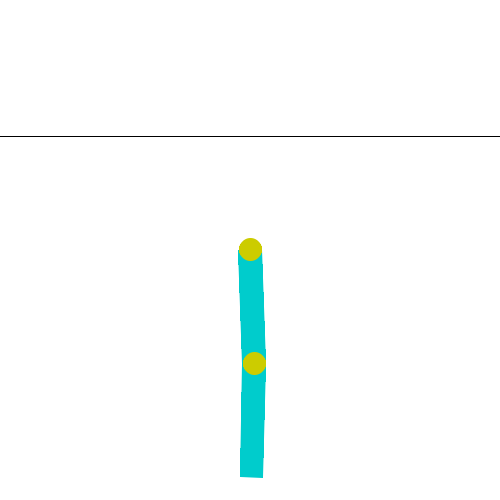

In [9]:
# GAE-advantage diagnostic on a fresh fixed-horizon batch built from the trained nets
def advantage_stats(steps: int = STEPS_PER_EPOCH) -> None:
    b = RolloutBuffer(steps)
    e = make_env(); o = e.reset()[0]
    for t in range(steps):
        obs_t = torch.tensor(o, dtype=torch.float32)
        with torch.no_grad():
            a = policy_net.sample(obs_t)
            v = critic_net(obs_t).item()
        o2, r, term, trunc, info = e.step(int(a)); b.append(obs_t, int(a), r, v); o = o2
        d = term or trunc
        timeout = trunc and not term
        epoch_ended = t == steps - 1
        if d or epoch_ended:
            genuine = d and not timeout and not epoch_ended
            with torch.no_grad():
                last_v = 0.0 if genuine else critic_net(torch.tensor(o, dtype=torch.float32)).item()
            b.finish_trajectory(last_v)
            o = e.reset()[0]
    e.close()
    obs_b, act_b, ret_b, adv_b = b.get_data()          # adv is precomputed GAE now
    adv = np.asarray(adv_b, np.float64)
    print(f"GAE advantage: mean {adv.mean():+.2f}  std {adv.std():.2f}  frac>0 {(adv>0).mean():.2f}  "
          f"min {adv.min():.1f}  max {adv.max():.1f}")

advantage_stats()

mean_ret, std_ret = evaluate(n_episodes=30)
print(f"\nV3 greedy return on {ENV_NAME}: {mean_ret:.1f} +/- {std_ret:.1f}")
print("Should stay in V1/V2 territory -- GAE is a variance change, not a capability jump.")
record_gif("v3_baseline.gif")


---
### When V3 is done
Ping me with your eval line + the `goals` progression and the GAE-advantage diagnostic, and I'll
review the `δ` recursion (the `V(s_{t+1})` indexing and the `γλ` discount are where GAE bugs hide)
before generating **V4 — PPO-clip**, which finally reuses this batch for *multiple* gradient passes
under a clipped surrogate objective — and that's the moment the rollout-time-frozen `val`/`adv` you
just built stops being a nicety and becomes load-bearing.
